In [10]:
import numpy as np
import pandas as pd
# 统计每一类假名样本数量
train_img_npz = np.load("kmnist-train-imgs.npz")
train_label_npz = np.load("kmnist-train-labels.npz")
img_3d = train_img_npz["arr_0"]
y_all = train_label_npz["arr_0"]
X_all = img_3d.reshape(img_3d.shape[0], -1)
np.random.seed(40)
sample_size = 9000
unique_cls = np.unique(y_all)
X_raw_list, y_raw_list = [], []
per_cls_sample = sample_size // len(unique_cls)
for c in unique_cls:
    idx_c = np.where(y_all == c)[0]
    sel_idx = np.random.choice(idx_c, size=per_cls_sample, replace=False)
    X_raw_list.append(X_all[sel_idx])
    y_raw_list.append(y_all[sel_idx])
X_raw = np.vstack(X_raw_list)
y_raw = np.hstack(y_raw_list)
cls_count = pd.Series(y_raw).value_counts().sort_index()
print("========== 各类别样本数量统计 ==========")
print(cls_count)

========== 各类别样本数量统计 ==========
0    900
1    900
2    900
3    900
4    900
5    900
6    900
7    900
8    900
9    900
Name: count, dtype: int64


实验总样本量：9000，原始特征维度：784
训练集样本量：7200，测试集样本量：1800

===== 1. PCA 线性降维 =====
PCA降至2维，前2主成分累计方差贡献率：0.1650
PCA降至3维，前3主成分累计方差贡献率：0.2056

===== 2. KPCA(RBF核) =====

===== 3. LLE 局部线性嵌入 =====

===== 4. ISOMAP 等距映射 =====

===== 5. MDS 多维尺度变换 =====

===== 6. t-SNE =====

==================== 2维/3维降维定量对比结果 ====================
           算法  嵌入维度  KNN分类准确率
0         PCA     2    0.3717
1         PCA     3    0.5128
2   KPCA(RBF)     2    0.3517
3   KPCA(RBF)     3    0.5389
4         LLE     2    0.6122
5         LLE     3    0.7178
6      ISOMAP     2    0.4583
7      ISOMAP     3    0.6278
8         MDS     2    0.0772
9         MDS     3    0.1500
10      t-SNE     2    0.9056
11      t-SNE     3    0.9056


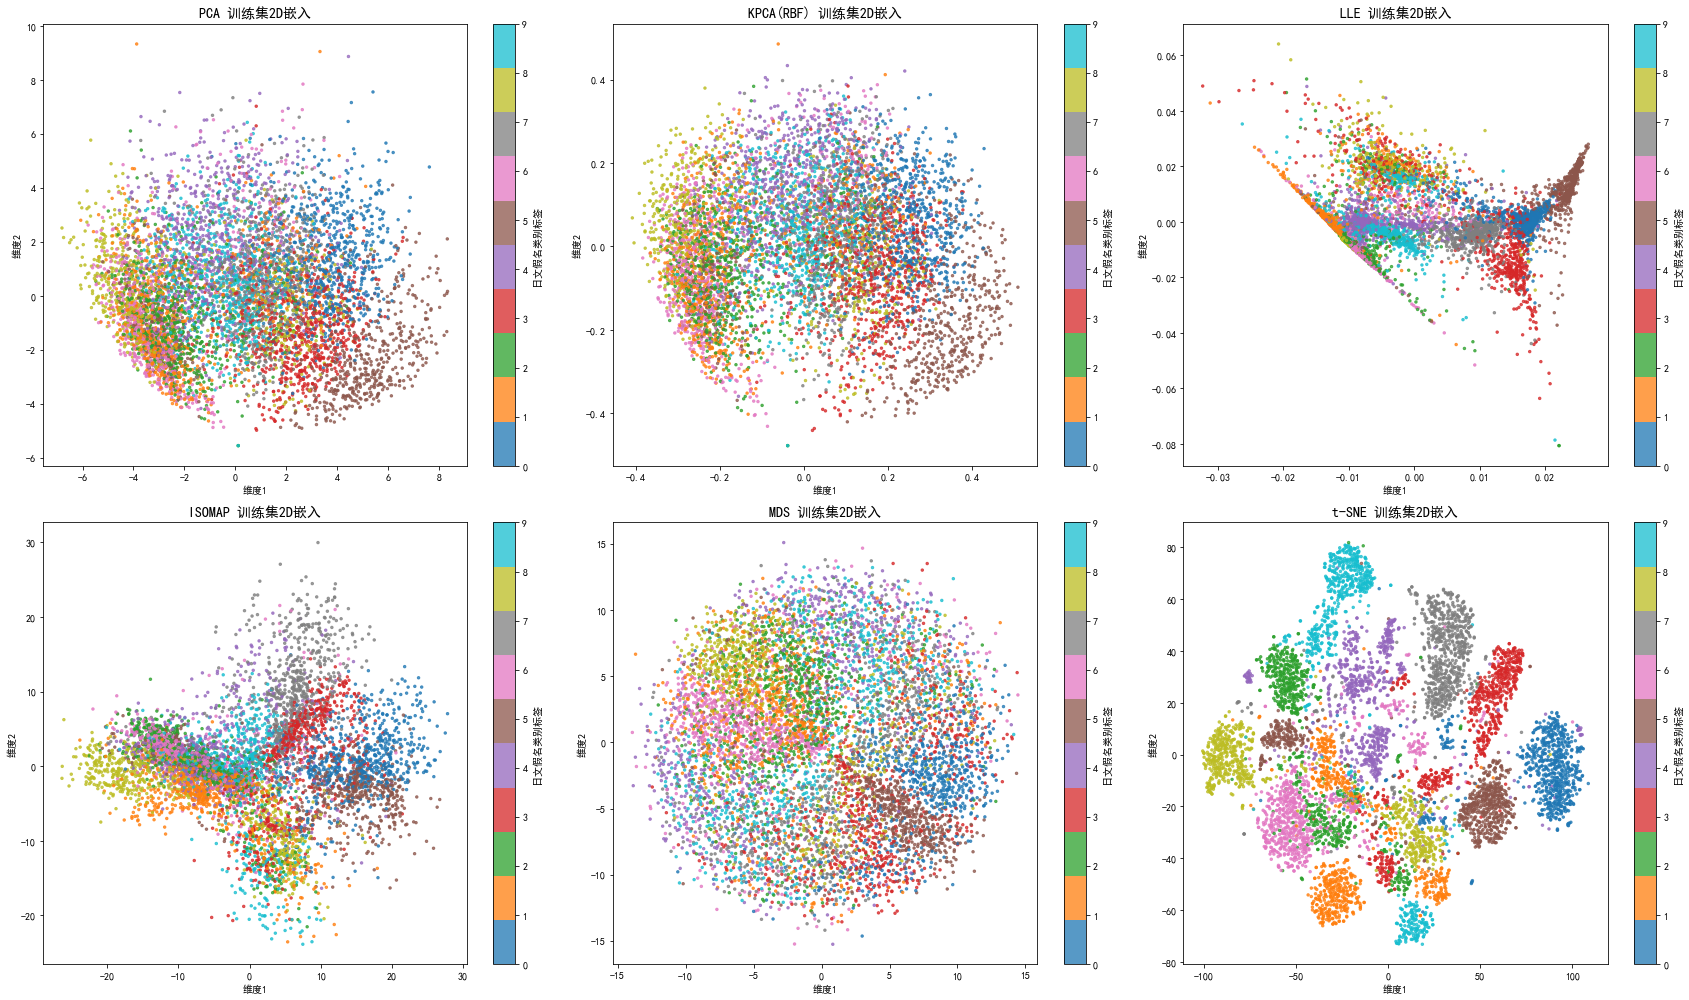

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE, Isomap, LocallyLinearEmbedding, MDS
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.utils import resample
train_img_npz = np.load("kmnist-train-imgs.npz")
train_label_npz = np.load("kmnist-train-labels.npz")

img_3d = train_img_npz["arr_0"]
y_all = train_label_npz["arr_0"]
X_all = img_3d.reshape(img_3d.shape[0], -1)

np.random.seed(40)
# 分层均衡采样
sample_size = 9000
unique_cls = np.unique(y_all)
X_raw_list, y_raw_list = [], []
per_cls_sample = sample_size // len(unique_cls)
for c in unique_cls:
    idx_c = np.where(y_all == c)[0]
    sel_idx = np.random.choice(idx_c, size=per_cls_sample, replace=False)
    X_raw_list.append(X_all[sel_idx])
    y_raw_list.append(y_all[sel_idx])
X_raw = np.vstack(X_raw_list)
y_raw = np.hstack(y_raw_list)

# 分层划分训练测试集
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=40, shuffle=True, stratify=y_raw
)

print(f"实验总样本量：{X_raw.shape[0]}，原始特征维度：{X_raw.shape[1]}")
print(f"训练集样本量：{X_train_raw.shape[0]}，测试集样本量：{X_test_raw.shape[0]}")

# 图像像素改用MinMax归一化，减少噪声放大
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

result_dict = {}
eval_record = []
knn_k = 7  # 增大K，降低噪声干扰
dim_list = [2, 3]  # 同时对比2维、3维降维

# KNN评估函数
def get_metrics(embed_train, embed_test, y_train, y_test):
    knn = KNeighborsClassifier(n_neighbors=knn_k)
    knn.fit(embed_train, y_train)
    acc = knn.score(embed_test, y_test)
    return round(acc, 4)

# 1.PCA
print("\n===== 1. PCA 线性降维 =====")
for d in dim_list:
    pca = PCA(n_components=d, random_state=42)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    key_name = f"PCA_{d}维"
    result_dict[key_name] = {"train": X_train_pca, "test": X_test_pca}
    var_sum = pca.explained_variance_ratio_.sum()
    print(f"PCA降至{d}维，前{d}主成分累计方差贡献率：{var_sum:.4f}")
    acc_pca = get_metrics(X_train_pca, X_test_pca, y_train, y_test)
    # 删除累计方差贡献率字段，仅保留算法、维度、准确率
    eval_record.append({
        "算法": "PCA",
        "嵌入维度": d,
        "KNN分类准确率": acc_pca
    })

# 2.KPCA(RBF)
print("\n===== 2. KPCA(RBF核) =====")
for d in dim_list:
    kpca = KernelPCA(n_components=d, kernel="rbf", gamma=5e-3, random_state=42)
    X_train_kpca = kpca.fit_transform(X_train_scaled)
    X_test_kpca = kpca.transform(X_test_scaled)
    key_name = f"KPCA(RBF)_{d}维"
    result_dict[key_name] = {"train": X_train_kpca, "test": X_test_kpca}
    acc_kpca = get_metrics(X_train_kpca, X_test_kpca, y_train, y_test)
    eval_record.append({
        "算法": "KPCA(RBF)",
        "嵌入维度": d,
        "KNN分类准确率": acc_kpca
    })

# 3.LLE
print("\n===== 3. LLE 局部线性嵌入 =====")
for d in dim_list:
    lle = LocallyLinearEmbedding(n_components=d, n_neighbors=20, random_state=42)
    X_train_lle = lle.fit_transform(X_train_scaled)
    X_test_lle = lle.transform(X_test_scaled)
    key_name = f"LLE_{d}维"
    result_dict[key_name] = {"train": X_train_lle, "test": X_test_lle}
    acc_lle = get_metrics(X_train_lle, X_test_lle, y_train, y_test)
    eval_record.append({
        "算法": "LLE",
        "嵌入维度": d,
        "KNN分类准确率": acc_lle
    })

# 4.ISOMAP
print("\n===== 4. ISOMAP 等距映射 =====")
for d in dim_list:
    isomap = Isomap(n_components=d, n_neighbors=20)
    X_train_iso = isomap.fit_transform(X_train_scaled)
    X_test_iso = isomap.transform(X_test_scaled)
    key_name = f"ISOMAP_{d}维"
    result_dict[key_name] = {"train": X_train_iso, "test": X_test_iso}
    acc_iso = get_metrics(X_train_iso, X_test_iso, y_train, y_test)
    eval_record.append({
        "算法": "ISOMAP",
        "嵌入维度": d,
        "KNN分类准确率": acc_iso
    })

# 5.MDS：训练、测试集分别独立拟合
print("\n===== 5. MDS 多维尺度变换 =====")
for d in dim_list:
    mds_train = MDS(n_components=d, random_state=42, n_init=1)
    X_train_mds = mds_train.fit_transform(X_train_scaled)
    mds_test = MDS(n_components=d, random_state=42, n_init=1)
    X_test_mds = mds_test.fit_transform(X_test_scaled)
    key_name = f"MDS_{d}维"
    result_dict[key_name] = {"train": X_train_mds, "test": X_test_mds}
    acc_mds = get_metrics(X_train_mds, X_test_mds, y_train, y_test)
    eval_record.append({
        "算法": "MDS",
        "嵌入维度": d,
        "KNN分类准确率": acc_mds
    })

# 6.t-SNE
print("\n===== 6. t-SNE =====")
for d in dim_list:
    tsne = TSNE(n_components=d, perplexity=50, max_iter=2500, random_state=42)
    X_train_tsne = tsne.fit_transform(X_train_scaled)
    # 测试集近邻匹配
    dist_train = euclidean_distances(X_test_scaled, X_train_scaled)
    nn_idx = np.argmin(dist_train, axis=1)
    X_test_tsne = X_train_tsne[nn_idx]
    key_name = f"t-SNE_{d}维"
    result_dict[key_name] = {"train": X_train_tsne, "test": X_test_tsne}
    acc_tsne = get_metrics(X_train_tsne, X_test_tsne, y_train, y_test)
    eval_record.append({
        "算法": "t-SNE",
        "嵌入维度": d,
        "KNN分类准确率": acc_tsne
    })


eval_df = pd.DataFrame(eval_record)
print("\n==================== 2维/3维降维定量对比结果 ====================")
print(eval_df.round(4))


plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

# 筛选全部2维算法名称
alg_2d_names = [k for k in result_dict.keys() if "_2维" in k]
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
axes = axes.flatten()
cmap = plt.cm.tab10

for idx, name in enumerate(alg_2d_names):
    ax = axes[idx]
    data_2d = result_dict[name]["train"]
    scatter = ax.scatter(data_2d[:, 0], data_2d[:, 1], c=y_train, cmap=cmap, s=6, alpha=0.75)
    alg_short = name.replace("_2维", "")
    ax.set_title(f"{alg_short} 训练集2D嵌入", fontsize=14)
    ax.set_xlabel("维度1")
    ax.set_ylabel("维度2")
    cbar = plt.colorbar(scatter, ax=ax, ticks=range(10))
    cbar.set_label("日文假名类别标签")

plt.tight_layout()
plt.savefig("kmnist_six_dim_reduce_2d_compare.png", dpi=300, bbox_inches="tight")
plt.show()

In [2]:
import numpy as np
import pandas as pd

# 读取Fashion-MNIST训练csv
train_df = pd.read_csv("fashion-mnist_train.csv")

# 1. 基础数据集信息
# 第一列为label，剩余784列均为pixel0~pixel783像素
label_col = "label"
pixel_cols = [col for col in train_df.columns if col.startswith("pixel")]

print("====== Fashion-MNIST 数据集基础信息 ======")
print(f"总样本数量：{train_df.shape[0]}")
print(f"单张图像像素特征维度：{len(pixel_cols)}")
print(f"图像尺寸：28×28灰度图")
print("\n")

# 2. 类别样本数量统计
class_count = train_df[label_col].value_counts().sort_index()
stat_table = pd.DataFrame({
    "服饰类别编码": class_count.index,
    "样本数量": class_count.values
})

print("====== 各类别样本数量统计表 ======")
print(stat_table.to_string(index=False))
print(f"\n数据集总类别数：{len(stat_table)}")
print(f"单类最大样本数：{stat_table['样本数量'].max()}")
print(f"单类最小样本数：{stat_table['样本数量'].min()}")

====== Fashion-MNIST 数据集基础信息 ======
总样本数量：60000
单张图像像素特征维度：784
图像尺寸：28×28灰度图


====== 各类别样本数量统计表 ======
 服饰类别编码  样本数量
      0  6000
      1  6000
      2  6000
      3  6000
      4  6000
      5  6000
      6  6000
      7  6000
      8  6000
      9  6000

数据集总类别数：10
单类最大样本数：6000
单类最小样本数：6000


均衡采样后总样本量：9000，原始像素特征维度：784
训练集样本量：7200，测试集样本量：1800


===== 1. PCA 线性降维 =====
PCA降至2维，前2主成分累计方差贡献率：0.4658
PCA降至3维，前3主成分累计方差贡献率：0.5252

===== 2. KPCA(RBF核) =====

===== 3. LLE 局部线性嵌入 =====

===== 4. ISOMAP 等距映射 =====

===== 5. MDS 多维尺度变换 =====

===== 6. t-SNE =====

==================== 2维/3维降维定量对比结果 ====================
           算法  嵌入维度  KNN分类准确率
0         PCA     2    0.5361
1         PCA     3    0.6328
2   KPCA(RBF)     2    0.5217
3   KPCA(RBF)     3    0.6294
4         LLE     2    0.6556
5         LLE     3    0.7178
6      ISOMAP     2    0.6033
7      ISOMAP     3    0.6839
8         MDS     2    0.0561
9         MDS     3    0.0461
10      t-SNE     2    0.8006
11      t-SNE     3    0.8017


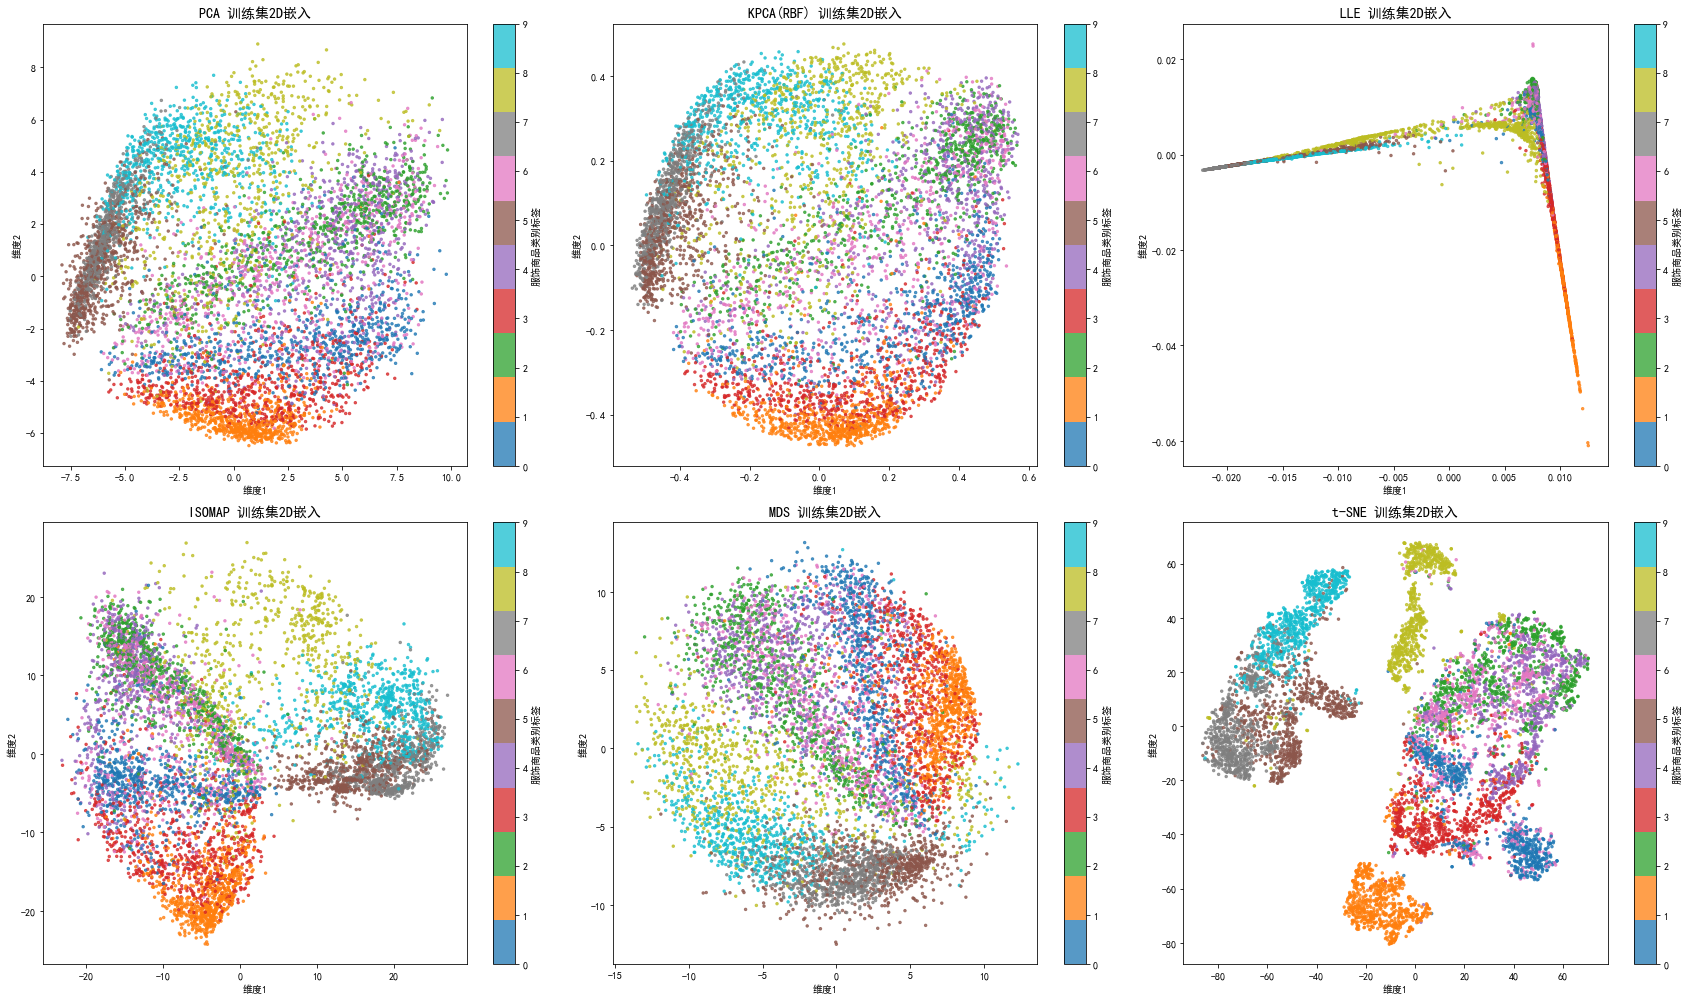

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE, Isomap, LocallyLinearEmbedding, MDS
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.metrics.pairwise import euclidean_distances

# 读取
train_df = pd.read_csv("fashion-mnist_train.csv")

# 分离标签与像素特征
y_all = train_df["label"].values
pixel_cols = [col for col in train_df.columns if col.startswith("pixel")]
X_all = train_df[pixel_cols].values

np.random.seed(40)
sample_size_target = 9000
unique_cls = np.unique(y_all)
n_class = len(unique_cls)
X_raw_list, y_raw_list = [], []

for c in unique_cls:
    idx_c = np.where(y_all == c)[0]
    class_total = len(idx_c)
    take_num = min(sample_size_target // n_class, class_total)
    sel_idx = np.random.choice(idx_c, size=take_num, replace=False)
    X_raw_list.append(X_all[sel_idx])
    y_raw_list.append(y_all[sel_idx])

X_raw = np.vstack(X_raw_list)
y_raw = np.hstack(y_raw_list)

# 分层划分训练集、测试集
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=40, shuffle=True, stratify=y_raw
)

print(f"均衡采样后总样本量：{X_raw.shape[0]}，原始像素特征维度：{X_raw.shape[1]}")
print(f"训练集样本量：{X_train_raw.shape[0]}，测试集样本量：{X_test_raw.shape[0]}\n")

# 像素归一化
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

result_dict = {}
eval_record = []
knn_k = 7
dim_list = [2, 3]

# KNN分类准确率评估函数
def get_metrics(embed_train, embed_test, y_train, y_test):
    knn = KNeighborsClassifier(n_neighbors=knn_k)
    knn.fit(embed_train, y_train)
    acc = knn.score(embed_test, y_test)
    return round(acc, 4)

# 1.PCA
print("\n===== 1. PCA 线性降维 =====")
for d in dim_list:
    pca = PCA(n_components=d, random_state=42)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    key_name = f"PCA_{d}维"
    result_dict[key_name] = {"train": X_train_pca, "test": X_test_pca}
    var_sum = pca.explained_variance_ratio_.sum()
    print(f"PCA降至{d}维，前{d}主成分累计方差贡献率：{var_sum:.4f}")
    acc_pca = get_metrics(X_train_pca, X_test_pca, y_train, y_test)
    eval_record.append({
        "算法": "PCA",
        "嵌入维度": d,
        "KNN分类准确率": acc_pca
    })

# 2.KPCA(RBF)
print("\n===== 2. KPCA(RBF核) =====")
for d in dim_list:
    kpca = KernelPCA(n_components=d, kernel="rbf", gamma=5e-3, random_state=42)
    X_train_kpca = kpca.fit_transform(X_train_scaled)
    X_test_kpca = kpca.transform(X_test_scaled)
    key_name = f"KPCA(RBF)_{d}维"
    result_dict[key_name] = {"train": X_train_kpca, "test": X_test_kpca}
    acc_kpca = get_metrics(X_train_kpca, X_test_kpca, y_train, y_test)
    eval_record.append({
        "算法": "KPCA(RBF)",
        "嵌入维度": d,
        "KNN分类准确率": acc_kpca
    })

# 3.LLE
print("\n===== 3. LLE 局部线性嵌入 =====")
for d in dim_list:
    lle = LocallyLinearEmbedding(n_components=d, n_neighbors=20, random_state=42)
    X_train_lle = lle.fit_transform(X_train_scaled)
    X_test_lle = lle.transform(X_test_scaled)
    key_name = f"LLE_{d}维"
    result_dict[key_name] = {"train": X_train_lle, "test": X_test_lle}
    acc_lle = get_metrics(X_train_lle, X_test_lle, y_train, y_test)
    eval_record.append({
        "算法": "LLE",
        "嵌入维度": d,
        "KNN分类准确率": acc_lle
    })

# 4.ISOMAP
print("\n===== 4. ISOMAP 等距映射 =====")
for d in dim_list:
    isomap = Isomap(n_components=d, n_neighbors=20)
    X_train_iso = isomap.fit_transform(X_train_scaled)
    X_test_iso = isomap.transform(X_test_scaled)
    key_name = f"ISOMAP_{d}维"
    result_dict[key_name] = {"train": X_train_iso, "test": X_test_iso}
    acc_iso = get_metrics(X_train_iso, X_test_iso, y_train, y_test)
    eval_record.append({
        "算法": "ISOMAP",
        "嵌入维度": d,
        "KNN分类准确率": acc_iso
    })

# 5.MDS
print("\n===== 5. MDS 多维尺度变换 =====")
for d in dim_list:
    mds_train = MDS(n_components=d, random_state=42, n_init=1)
    X_train_mds = mds_train.fit_transform(X_train_scaled)
    mds_test = MDS(n_components=d, random_state=42, n_init=1)
    X_test_mds = mds_test.fit_transform(X_test_scaled)
    key_name = f"MDS_{d}维"
    result_dict[key_name] = {"train": X_train_mds, "test": X_test_mds}
    acc_mds = get_metrics(X_train_mds, X_test_mds, y_train, y_test)
    eval_record.append({
        "算法": "MDS",
        "嵌入维度": d,
        "KNN分类准确率": acc_mds
    })

# 6.t-SNE
print("\n===== 6. t-SNE =====")
for d in dim_list:
    tsne = TSNE(n_components=d, perplexity=50, max_iter=2500, random_state=42)
    X_train_tsne = tsne.fit_transform(X_train_scaled)
    dist_train = euclidean_distances(X_test_scaled, X_train_scaled)
    nn_idx = np.argmin(dist_train, axis=1)
    X_test_tsne = X_train_tsne[nn_idx]
    key_name = f"t-SNE_{d}维"
    result_dict[key_name] = {"train": X_train_tsne, "test": X_test_tsne}
    acc_tsne = get_metrics(X_train_tsne, X_test_tsne, y_train, y_test)
    eval_record.append({
        "算法": "t-SNE",
        "嵌入维度": d,
        "KNN分类准确率": acc_tsne
    })

eval_df = pd.DataFrame(eval_record)
print("\n==================== 2维/3维降维定量对比结果 ====================")
print(eval_df.round(4))

plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

alg_2d_names = [k for k in result_dict.keys() if "_2维" in k]
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
axes = axes.flatten()
cmap = plt.cm.tab10

for idx, name in enumerate(alg_2d_names):
    ax = axes[idx]
    data_2d = result_dict[name]["train"]
    scatter = ax.scatter(data_2d[:, 0], data_2d[:, 1], c=y_train, cmap=cmap, s=6, alpha=0.75)
    alg_short = name.replace("_2维", "")
    ax.set_title(f"{alg_short} 训练集2D嵌入", fontsize=14)
    ax.set_xlabel("维度1")
    ax.set_ylabel("维度2")
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("服饰商品类别标签")

plt.tight_layout()
# plt.savefig("fashion_six_dim_reduce_2d_compare.png", dpi=300, bbox_inches="tight")
plt.show()